<a href="https://colab.research.google.com/github/PranshuSingh10/bMLll/blob/main/BML_lca_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing req libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

file uploading

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
           'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
           'hours-per-week', 'native-country', 'income']

data = pd.read_csv(url, header=None, names=columns, na_values=" ?", skipinitialspace=True)

dataset

In [ ]:
print("First 5 rows of the dataset:")
print(data.head())
print("\n Dataset shape:", data.shape)
print("\n Info:")
print(data.info())

First 5 rows of the dataset:
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1            

cleaning

In [ ]:
data.dropna(inplace=True)


visualization

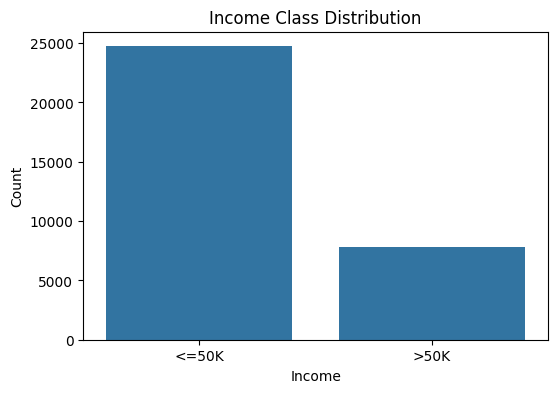

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='income', data=data)
plt.title("Income Class Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

Preprocess the Data

In [ ]:
X = data.drop('income', axis=1)
y = data['income']
X = pd.get_dummies(X)
y = y.map({'<=50K': 0, '>50K': 1})

 Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


Train Naïve Bayes Classifier

In [ ]:
model = GaussianNB()
model.fit(X_train, y_train)


GaussianNB()

Predict and Evaluate

In [ ]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Naïve Bayes classifier: {accuracy:.4f}")

Accuracy of Naïve Bayes classifier: 0.7993


Confusion Matrix

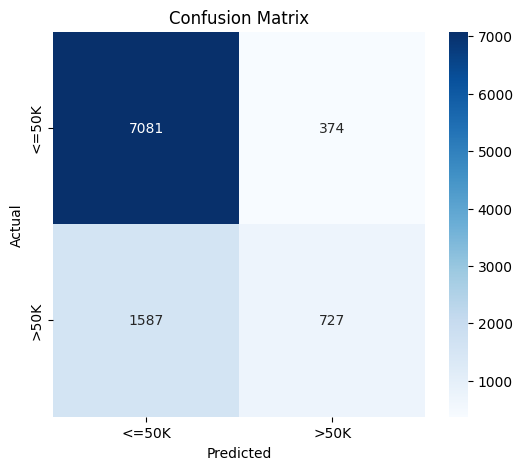

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Classification Report

In [ ]:
report = classification_report(y_test, y_pred, output_dict=True)

report_df = pd.DataFrame(report).transpose()

report_df = report_df.round(2)

print("Classification Report (Table Format):")
print(report_df[['precision', 'recall', 'f1-score', 'support']])

Classification Report (Table Format):
              precision  recall  f1-score  support
0                  0.82    0.95      0.88   7455.0
1                  0.66    0.31      0.43   2314.0
accuracy           0.80    0.80      0.80      0.8
macro avg          0.74    0.63      0.65   9769.0
weighted avg       0.78    0.80      0.77   9769.0
